In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# ***Task2***

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

In [ ]:
task2_df_path='/content/drive/MyDrive/Rajdeep_Document/data/Task_2/test.jsonl'
df_task2=pd.read_json(task2_df_path, lines=True)
pd.set_option('display.max_colwidth', None)
display(df_task2.sample(10))
print(df_task2.shape)

,text,label
50,"And so when we move all the items through and looked at what we expect the return of profitability in 2010, we did have impairment.",0
32,"Our cost-effective fibre-based solutions are made from a renewable resource, and are lightweight, recyclable and biodegradable.",1
207,"The Chairman of the Remuneration Committee discussed the draft Policy with the European Works Council, while the Chairman of the Supervisory Board discussed it with the Central Works Council in the Netherlands.",0
87,It helps the overall balance of fossil fuel and nonfossil fuel.,0
20,No we’re including the puts and takes and just to talk a little bit about the transition.,0
71,Chotia Block with reserves of 15.5 mt and annual production capacity of 1mtpa;,0
247,"Our recent report, Building the Net Zero Energy Workforce, looks at the skills and expertise the energy sector will need to help the UK reach its emissions target.",0
108,"So on the coal side, P.J., part of what is helping on the coal is a little bit of government hand in terms of managing output production at the mine.",0
250,"And then with energy efficiency, on the consumer side of things, we're seeing more people comfortable with maybe lower surplus reserves and being able to delay some of their CapEx decisions.",0
241,"And I was talking to my team here in between and I neglected to mention about the payroll taxes that shows up in the first quarter, where that's $1.5 million or so higher than the normal other quarters.",0


(265, 2)


In [ ]:
#clean function
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)
    return text.strip()

In [ ]:
df_task2['clean_text'] = df_task2['text'].apply(clean_text)
display(df_task2.sample(10))

,text,label,clean_text
140,"The essence of digital farming consists in aggregating and creating value from data, which is no longer sourced merely from farm equipment but is also generated using new services and algorithms and transformed into actionable intelligence.",0,the essence of digital farming consists in aggregating and creating value from data which is no longer sourced merely from farm equipment but is also generated using new services and algorithms and transformed into actionable intelligence
59,"And again, as we've talked about repeatedly, we are very, very focused on driving cost efficiencies, and that's starting to show up in our results from a North American perspective.",0,and again as weve talked about repeatedly we are very very focused on driving cost efficiencies and thats starting to show up in our results from a north american perspective
167,• Fugitive emissions of methane (CH4) (storage and transport of natural gas).,0,fugitive emissions of methane ch4 storage and transport of natural gas
203,"Keep in mind, again, in Q2, there will continue to remain pressure on our gross margin as a result of having the incremental flagship cost that we didn't have last year in that quarter similar to Q1.",0,keep in mind again in q2 there will continue to remain pressure on our gross margin as a result of having the incremental flagship cost that we didnt have last year in that quarter similar to q1
155,(e) TSPL had entered into a long term Power Purchase Agreement (“PPA”) with Punjab State Power Corporation Limited (“PSPCL”) for supply of power.,0,e tspl had entered into a long term power purchase agreement ppa with punjab state power corporation limited pspcl for supply of power
84,"During con- struction, operation and dismantling of our power plants and networks, we take necessary measures to reduce noise and emissions.",1,during con struction operation and dismantling of our power plants and networks we take necessary measures to reduce noise and emissions
186,"All acquisitions are assessed according to stringent financial criteria, with the most important being that ROACE should move into the Group target range of 12–15 per cent in the medium-term.",0,all acquisitions are assessed according to stringent financial criteria with the most important being that roace should move into the group target range of 1215 per cent in the mediumterm
8,"During Capital Markets Day 2020, Hydro announced a new and extended improvement ambition, now aiming to achieve improvements of NOK 8.5 billion by 2025.",0,during capital markets day 2020 hydro announced a new and extended improvement ambition now aiming to achieve improvements of nok 85 billion by 2025
128,It contains 100% renewable carbon and thus meets ISO standard 16128 on natural and organic cosmetics.,1,it contains 100 renewable carbon and thus meets iso standard 16128 on natural and organic cosmetics
234,"So year-over-year, again, we're going to shrink that deficit by probably at least $60 million, $70 million.",0,so yearoveryear again were going to shrink that deficit by probably at least 60 million 70 million


In [ ]:
df_task2 = df_task2.drop(columns='text')
display(df_task2.sample(5))

,label,clean_text
107,1,gazprom strictly complies with environmental laws and takes measures to minimize adverse environmental impacts and preserve 411
16,0,hydrocarbon spills with an environmental impact spills with a volume greater than 1 barrel 159 liters are counted
249,0,we continue to remain committed to achieving our target operating margin range or beyond
264,0,however as shown in figure 14 this is not the case and our carbon intensity has remained relatively constant
187,1,throughout the year bluescope maintained focus on conducting business in a sustainable way with progress across our most material sustainability focus areas


In [ ]:
# EDA
print("Shape:", df_task2.shape)
print("Label Distribution:\n", df_task2['label'].value_counts())
print("Missing:\n", df_task2.isnull().sum())

Shape: (265, 2)
Label Distribution:
 label
0    198
1     67
Name: count, dtype: int64
Missing:
 label         0
clean_text    0
dtype: int64


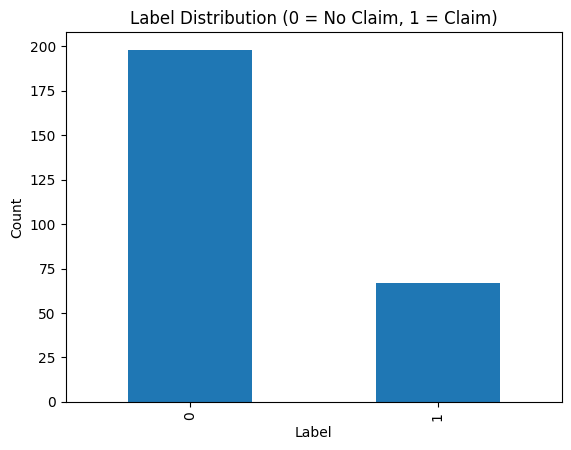

In [ ]:
df_task2['label'].value_counts().plot(kind='bar')
plt.title("Label Distribution (0 = No Claim, 1 = Claim)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

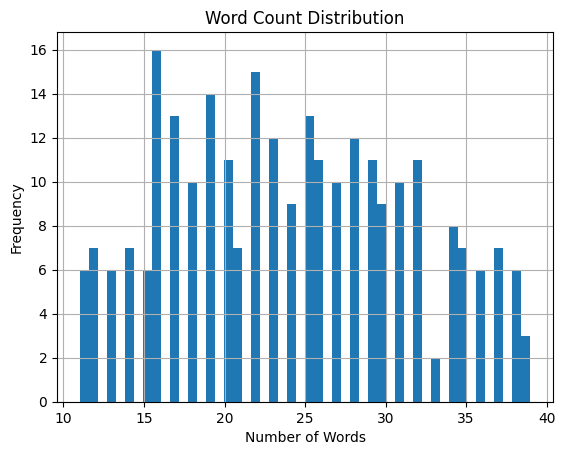

In [ ]:
df_task2['word_count'] = df_task2['clean_text'].apply(lambda x: len(x.split()))

df_task2['word_count'].hist(bins=50)
plt.title("Word Count Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

In [ ]:
from collections import Counter

# Define english_stopwords if it's not already defined
if 'english_stopwords' not in locals() and 'english_stopwords' not in globals():
    english_stopwords = {
        'a', 'an', 'and', 'are', 'as', 'at', 'be', 'been', 'being', 'by', 'for', 'from',
        'has', 'have', 'he', 'her', 'his', 'how', 'if', 'in', 'is', 'it', 'its', 'of',
        'on', 'or', 'our', 'that', 'the', 'their', 'them', 'then', 'there', 'these',
        'they', 'this', 'those', 'through', 'to', 'was', 'we', 'what', 'when', 'where',
        'which', 'while', 'who', 'whom', 'why', 'with', 'you', 'your','but'
    }

# Filter out stopwords before joining and splitting
filtered_text_task2 = df_task2['clean_text'].apply(lambda x: ' '.join([word for word in x.split() if word not in english_stopwords]))
all_words_task2 = " ".join(filtered_text_task2).split()
common_words_task2 = Counter(all_words_task2).most_common(20)

print(common_words_task2)

[('energy', 48), ('will', 29), ('environmental', 24), ('business', 23), ('so', 22), ('i', 20), ('year', 18), ('were', 18), ('all', 18), ('emissions', 18), ('carbon', 18), ('power', 17), ('us', 17), ('gas', 17), ('new', 16), ('renewable', 16), ('climate', 16), ('production', 16), ('continue', 14), ('also', 13)]


In [ ]:
print("Task 2 duplicates:", df_task2.duplicated().sum())

Task 2 duplicates: 0


In [ ]:
df_task2 = df_task2.rename(columns={'clean_text': 'text'})
display(df_task2.sample(5))

,label,text,word_count
90,0,and i think we have good line of sight to seeing continued growth in that asset for the long term,20
172,0,for these reasons we consider climate change countermeasures to be a major component of sustainability management,16
157,0,but at this point its too early to say anything other than we are still committed to our 135 billion through 2021,22
209,0,if you look at our construction expenditures what the biggest items the next big item will be the aero derivates gas turbine in 2013,24
183,1,with the groups 2030 carbon emission reduction goal for our own operations met the board also considered the development of new internal carbon energy and travel targets,27


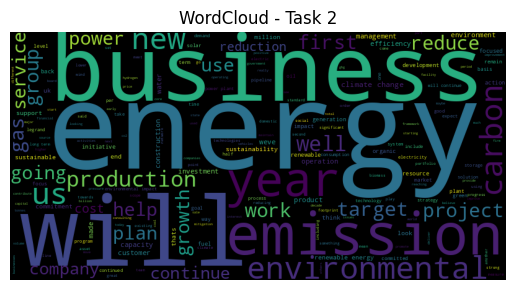

In [ ]:
from wordcloud import WordCloud

wc_task2 = WordCloud(width=800, height=400).generate(" ".join(df_task2['text']))

plt.imshow(wc_task2)
plt.axis("off")
plt.title("WordCloud - Task 2")
plt.show()

In [ ]:
df_task2[['text', 'label']].to_csv('/content/drive/MyDrive/Rajdeep_Document/data/Task_2/cleaned_task2.csv', index=False)

## ***TASK 3***

In [ ]:
df_task3_path='/content/drive/MyDrive/Rajdeep_Document/data/Task_3/SemEval2016-Task6-subtaskA-testdata-gold.txt'
df_task3 = pd.read_csv(df_task3_path, sep='\t')
display(df_task3)

,ID,Target,Tweet,Stance,Opinion towards,Sentiment
0,10001,Atheism,He who exalts himself shall be humbled; and he who humbles himself shall be exalted.Matt 23:12. #SemST,AGAINST,TARGET,POSITIVE
1,10002,Atheism,"RT @prayerbullets: I remove Nehushtan -previous moves of God that have become idols, from the high places -2 Kings 18:4 #SemST",AGAINST,TARGET,NEITHER
2,10003,Atheism,@Brainman365 @heidtjj @BenjaminLives I have sought the truth of my soul and found it strong enough to stand on its own merits. #SemST,AGAINST,TARGET,POSITIVE
3,10004,Atheism,#God is utterly powerless without Human intervention... #SemST,AGAINST,TARGET,NEGATIVE
4,10005,Atheism,@David_Cameron Miracles of #Multiculturalism Miracles of shady 786 #Taqiya #Tawriya #Jaziya #Kafirs #Dhimmi #Jihad #Allah #SemST,AGAINST,OTHER,NEGATIVE
...,...,...,...,...,...,...
1244,11245,Legalization of Abortion,@MetalheadMonty @tom_six I followed him before I watched human centipede 3.....i now hope never makes another film again #SemST,NONE,OTHER,NEGATIVE
1245,11246,Legalization of Abortion,"For he who avenges blood remembers, he does not ignore the cry of the afflicted. ~ Ps 9:12 #comequicklyLordJesus #SemST",AGAINST,TARGET,NEITHER
1246,11247,Legalization of Abortion,Life is sacred on all levels. Abortion does not compute with my philosophy. Kate Mulgrew @TheKateMulgrew (Red on #OITNB ) #SemST,AGAINST,TARGET,NEITHER
1247,11248,Legalization of Abortion,"@ravensymone U refer to ""WE"" which =""YOU"" & a minority of idiots who support #suicide #murder #death #iLLegalAliens #RavenSymone #SemST",AGAINST,TARGET,NEGATIVE


In [ ]:
df_task3 = df_task3.rename(columns={'Tweet': 'text', 'Stance': 'label'})
display(df_task3.sample(5))

,ID,Target,text,label,Opinion towards,Sentiment
1115,11116,Legalization of Abortion,To run outside? To run inside? #SemST,NONE,OTHER,NEITHER
512,10513,Feminist Movement,Ladies is pimps too. Go on brush your shoulders off. #SemST,FAVOR,TARGET,NEGATIVE
1085,11086,Legalization of Abortion,@ConnectCatholic The justification of abortion is rooted in selfishness & fear & they come from lack of faith & self centeredness #SemST,AGAINST,TARGET,NEGATIVE
355,10356,Climate Change is a Real Concern,"$500,000 on flags in 12 months vs An Inter-Generational Rot that addresses #ThingsToSpendMyTaxesOnOtherThanFlags #SemST",NONE,OTHER,NEGATIVE
188,10189,Atheism,"IF GOD BROUGHT YOU TO IT , HE'LL BRING YOU THROUGH IT. #GODKNOWS #WHATHEDOING #BEPATIENT #TRUSTANDBELIEVE #SemST",AGAINST,OTHER,POSITIVE


In [ ]:
print(df_task3['label'].unique())

['AGAINST' 'FAVOR' 'NONE']


In [ ]:
df2_task3=df_task3.copy()

In [ ]:
df_task3['label'] = df_task3['label'].astype(str).str.strip()

In [ ]:
print(df_task3['label'].unique())

['AGAINST' 'FAVOR' 'NONE']


In [ ]:
label_map_t3 = {
    "FAVOR": 1,
    "AGAINST": 0,
    "NONE": 2
}

df_task3['label'] = df_task3['label'].map(label_map_t3)
display(df_task3.sample(10))

,ID,Target,text,label,Opinion towards,Sentiment
543,10544,Feminist Movement,Not catering to a woman that doesn't bring = amount to the table as I do. #equality #SemST,0,TARGET,NEGATIVE
1085,11086,Legalization of Abortion,@ConnectCatholic The justification of abortion is rooted in selfishness & fear & they come from lack of faith & self centeredness #SemST,0,TARGET,NEGATIVE
873,10874,Hillary Clinton,I wish #OliviaPope could run @HillaryClinton 's campaign... #Scandal #livisreal #SemST,0,TARGET,NEGATIVE
520,10521,Feminist Movement,Also Tatum's feigns giving oral in a hands free headstand. SEE THIS FILM. #SemST,2,OTHER,POSITIVE
804,10805,Hillary Clinton,Hillary upset GOP candidates didn't respond to Trump's illegal imm comments immediately-yet we're still waiting for her emails. #SemST,0,TARGET,NEGATIVE
1229,11230,Legalization of Abortion,"Fallopians 3:16 ""Not your fuckin' pregnancy - not your fuckin' business!"" #SemST",1,TARGET,NEGATIVE
497,10498,Feminist Movement,"MARRIAGE for a man is MURDERAGE, That's right MURDER'RAGE! Women have ruined the trust of men, and destabilized their own future. #SemST",0,TARGET,NEGATIVE
209,10210,Atheism,Ya....cuz Nicky Hilton HAD to marry up? Really? You had to land a bloody Rothschild too?? #SemST,2,OTHER,NEGATIVE
205,10206,Atheism,"AtheistQ ""God's guidance is the only excuse for a man who can't find a better justification for his actions. #SemST",1,TARGET,NEGATIVE
27,10028,Atheism,"Father, grant us grace to remain holy and a vessel of honour in ur house. #OpenHeaven #NatiVarietySunday #SundayMorningShow #SemST",0,TARGET,POSITIVE


In [ ]:
df_task3['text'] = df_task3['text'].apply(clean_text)
display(df_task3.sample(10))

,ID,Target,text,label,Opinion towards,Sentiment
15,10016,Atheism,iloveislambecause and v should love islam because its a deen instead of just a semst,0,TARGET,POSITIVE
420,10421,Feminist Movement,thanks to sjw i now associate the word trigger with a joke and im going to offend an actual ptsd victim semst,0,OTHER,NEGATIVE
59,10060,Atheism,the deeper i go with in the deeper the silence the peace the healing the clarity the vision the belief the deeper my semst,0,TARGET,POSITIVE
937,10938,Hillary Clinton,at the end of the day support the candidate wbest chance of beating the progressive democrat dont stay home uniteright semst,0,OTHER,POSITIVE
618,10619,Feminist Movement,rapeculture is leaving your newused car in the worst neighborhood doors wide open not to expect cartheftculture semst,0,OTHER,NEGATIVE
658,10659,Feminist Movement,im okay with white girls with dreads because semst,2,OTHER,POSITIVE
250,10251,Climate Change is a Real Concern,also whats up with this ridiculous weather it was raining this morning and now its like super hot weatherproblems lame semst,1,TARGET,NEGATIVE
26,10027,Atheism,jagannathazad a hindu was asked by founder of pakistan to write the first national anthem semst,0,TARGET,NEITHER
296,10297,Climate Change is a Real Concern,we blame cities for the majority of co2 emissions without acknowledging their vulnerability to cfcc15 journey2015 s2228 semst,1,TARGET,NEGATIVE
1229,11230,Legalization of Abortion,fallopians 316 not your fuckin pregnancy not your fuckin business semst,1,TARGET,NEGATIVE


In [ ]:
print("Task 3 duplicates:", df_task3.duplicated().sum())

Task 3 duplicates: 0


In [ ]:
print("Shape:", df_task3.shape)
print("Label Distribution:\n", df_task3['label'].value_counts())

Shape: (1249, 6)
Label Distribution:
 label
0    715
1    304
2    230
Name: count, dtype: int64


In [ ]:
df_task3[['text', 'label']].to_csv('/content/drive/MyDrive/Rajdeep_Document/data/Task_3/cleaned_task3.csv', index=False)



---



## ***Task4***

In [ ]:
task4_df_path='/content/drive/MyDrive/Rajdeep_Document/data/Task_4/climate_bert.csv'
df_task4=pd.read_csv(task4_df_path)
pd.set_option('display.max_colwidth', None)
display(df_task4.sample(10))

,Unnamed: 0,text,label
195,195,"While we seek to partner with organizations that mitigate their business risks associated with climate change, we recognize that there are inherent risks wherever business is conducted. Access to clean water and reliable energy in the communities where we conduct our business, whether for our offices or for our vendors, is a priority. Our major sites in California, Utah and India are vulnerable to prolonged droughts due to climate change. In the event of a natural disaster that disrupts business due to limited access to these resources, we have the potential to experience losses to our business, and added costs to resume operations. To accurately assess and take potential proactive action as appropriate, Adobe is aligned with the guidelines of the Financial Stability Board’s (“FSB”) Task Force on Climate-related Financial Disclosures (“TCFD”) recommendations.",0
207,207,"18 flooding. As the pressures from climate change and global population growth lead to increased demand, the food system and global supply chain is becoming increasingly vulnerable to acute shocks, leading to increased prices and volatility, especially in the energy and commodity markets. Adverse changes such as these could: • unfavorably impact the cost or availability of raw or packaging materials, especially if such events have a negative impact on agricultural productivity or on the supply of water; • disrupt our ability, or the ability of our suppliers or contract manufacturers, to manufacture or distribute our products; • disrupt the retail operations of our customers; or • unfavorably impact the demand for, or the consumer's ability to purchase, our products.",0
222,222,"All these risks can generate a series of impacts for our Company, such as financial losses in Distribution and network maintenance services, payment of fines for interruption of power supply, reduction of hydroelectric power generation - and consequent deficits in Generation Scaling Factor - GSF and higher free market price volatility.",0
149,149,"Furthermore, according to the United Nations Environment Programme's (UNEP) latest Emissions Gap Report, 1.5°C will involve “expanding renewable energy for electrification, phasing out coal for rapid decarbonisation of the energy system, decarbonising transport with a focus on electric mobility, decarbonising energy-intensive industry and avoiding future emissions, while improving energy access”;4 all very challenging actions.",1
187,187,"2019 also saw the continuation of activities regarding lighting, with widespread use of LED technology, both in motorway tunnels and airports, as well as in buildings, which reduced electrical energy consumption by around 5.4 GWh. As regards air conditioning, modernisation of the systems continued, with more efficient machinery, such as refrigeration units, significant results have been obtained with monitoring and diagnostic platforms that have reduced waste, for a total saving of 3.7 Gwh of electricity.",2
138,138,"The Company maintains in-depth emergency response measures for extreme weather events. When planning for capital investment or acquiring assets, we consider site specific climate and weather factors, such as flood plain mapping and extreme weather history.",0
167,167,"With reference to the reuse of materials, the projects created in implementation of the Group’s investment plans for the Italian motorway network provided for the reuse - within the regulatory limits - of the earth deriving from excavations, in order to mitigate the environmental impact linked mainly to the procurement of inert quarry materials and the disposal in landfills of unused materials. They are reused to create embankments, landscaping and noise-absorbing dunes, as well as for the redevelopment of degraded areas (such as abandoned quarries).",2
13,13,"We emit greenhouse gases both directly and indirectly. Our direct (scope one) emissions come from our industrial businesses, including the use 

In [ ]:
df_task4 = df_task4.drop(columns=['Unnamed: 0'])

In [ ]:
df_task4['text'] = df_task4['text'].apply(clean_text)
display(df_task4.sample(10))

,text,label
124,as a natural resources industry we have a profound responsibility to address the planets undisputed warming and adapt to the future impacts it remains a high profile challenge across our markets countries like india in which we are operating are predicted to experience the worst impact of climate change as it is a coal consuming economy,0
86,the scenarios developed by the iea were used as the frame of reference above 32c currentpolicies scenario this scenario is a baseline picture of how global energy markets would evolve if governments make no changes to their existing policies and measures 27c to 32c statedpolicies scenario this scenario reflects the impact of existing policy frameworks and todays announced policy intentions 175c to 2c sustainable development scenario this iea scenario is most aligned with the paris agreement as it holds the temperature rise to below 18c with a 66 probability without reliance on global netnegative co2 emissions this is equivalent to limiting the temperature rise to 165c with a 50 probability,1
227,next lets turn to the financials fy18 revenue of 29953 billion grew 5 percent on a comparable constant currency basis fy18 non gaap diluted earnings per share grew 9 percent on a comparable basis or 10 percent on a comparable constant currency basis the second half of the year was particularly strong overcoming several first half challenges including an it disruption multiple hurricanes wildfires in santa rosa and supply constraints in diabetes we delivered on our revenue and eps guidance we established at the start of the year we also continued to drive margin expansion reduced debt leverage and returned 43 billion to shareholders in the form of dividends and share repurchases,0
17,internal reputation we also support a business culture where employees help employees the vtov employee relief fund pro vides aid for verizon employees displaced from their homes due to a natural or personal emergency such as fire flood severe weather or domestic violence vtov has provided grants to verizon employees around the world to use toward food clothing shelter and other necessities during lifechanging disasters,1
57,managing weather impacts tropical cyclones hurricanes and typhoons present a risk to our coastal and inland infrastructure includ ing our network and facilities these events may increase our capital and operating costs to maintain andor repair our facilities following the event every year we make significant investments in real estate and net work maintenance and upgrades to build resilience into our operational infrastructure based on the lessons learned during storms such as superstorm sandy hurricane matthew and hurricane michael we have taken steps to increase the resilience of our network in affected areas and other atrisk areas depending on the area and risk these steps to enhance infrastructure resilience have included adding stilts to raise equipment that powers cell sites moving site generators from basements to a higher level or platforms and installing new fiber solutions underground rather than using aerial fiber we also have ongoing efforts to improve backup facility power systems including power capacity at facilities located in areas with greater storm and wildfire risk by adding generators to atrisk sites where historically the site only had backup batteries federal state and local regulators may create requirements that change the type and timing of actions we take which could result in higher operating costs than anticipated,0
261,energy infrastructure revenues of 195 million in the full year of 2020 were 661 million lower than the same period in 2019 mainly due to the sale of the canadian fossil fuelbased electricity generation business and alberta powerline in 2019,1
206,d this client does not yet meet rabobanks sustainability policy on one or more points or has not responded adequately to key questions specific agreements are made about a possible solution and ti

In [ ]:
print("Task 4 duplicates:", df_task4.duplicated().sum())

Task 4 duplicates: 0


In [ ]:
print("Shape:", df_task4.shape)
print("Label Distribution:\n", df_task4['label'].value_counts())

Shape: (320, 2)
Label Distribution:
 label
1    163
0    106
2     51
Name: count, dtype: int64


In [ ]:
df_task4[['text', 'label']].to_csv('/content/drive/MyDrive/Rajdeep_Document/data/Task_4/cleaned_task4.csv', index=False)

## Word Count and Unique Word Analysis for Raw and Cleaned Text

In [ ]:
def analyze_text_column(df, column_name):
    """Calculates total word count and total unique word count for a text column."""
    total_words = df[column_name].astype(str).apply(lambda x: len(x.split())).sum()
    all_words = " ".join(df[column_name].dropna().astype(str)).split()
    unique_words = len(set(all_words))
    return total_words, unique_words

print("### Task 2 Analysis")
# Raw text analysis for Task 2
task2_df_path='/content/drive/MyDrive/Rajdeep_Document/data/Task_2/test.jsonl'
df_task2_raw = pd.read_json(task2_df_path, lines=True)
raw_wc_t2, raw_uwc_t2 = analyze_text_column(df_task2_raw, 'text')
print(f"Task 2 Raw Text: Total Words = {raw_wc_t2}, Unique Words = {raw_uwc_t2}")

# Cleaned text analysis for Task 2 (using the existing df_task2 which has 'clean_text' renamed to 'text')
cleaned_wc_t2, cleaned_uwc_t2 = analyze_text_column(df_task2, 'text')
print(f"Task 2 Cleaned Text: Total Words = {cleaned_wc_t2}, Unique Words = {cleaned_uwc_t2}")

### Task 2 Analysis
Task 2 Raw Text: Total Words = 6423, Unique Words = 2490
Task 2 Cleaned Text: Total Words = 6399, Unique Words = 2027


In [ ]:
print("\n### Task 3 Analysis")
# Raw text analysis for Task 3
df_task3_path='/content/drive/MyDrive/Rajdeep_Document/data/Task_3/SemEval2016-Task6-subtaskA-testdata-gold.txt'
df_task3_raw = pd.read_csv(df_task3_path, sep='\t')
df_task3_raw = df_task3_raw.rename(columns={'Tweet': 'text', 'Stance': 'label'})
raw_wc_t3, raw_uwc_t3 = analyze_text_column(df_task3_raw, 'text')
print(f"Task 3 Raw Text: Total Words = {raw_wc_t3}, Unique Words = {raw_uwc_t3}")

# Cleaned text analysis for Task 3
cleaned_wc_t3, cleaned_uwc_t3 = analyze_text_column(df_task3, 'text')
print(f"Task 3 Cleaned Text: Total Words = {cleaned_wc_t3}, Unique Words = {cleaned_uwc_t3}")


### Task 3 Analysis
Task 3 Raw Text: Total Words = 21612, Unique Words = 7692
Task 3 Cleaned Text: Total Words = 21364, Unique Words = 5512


In [ ]:
print("\n### Task 4 Analysis")
# Raw text analysis for Task 4
task4_df_path='/content/drive/MyDrive/Rajdeep_Document/data/Task_4/climate_bert.csv'
df_task4_raw = pd.read_csv(task4_df_path)
raw_wc_t4, raw_uwc_t4 = analyze_text_column(df_task4_raw, 'text')
print(f"Task 4 Raw Text: Total Words = {raw_wc_t4}, Unique Words = {raw_uwc_t4}")

# Cleaned text analysis for Task 4
cleaned_wc_t4, cleaned_uwc_t4 = analyze_text_column(df_task4, 'text')
print(f"Task 4 Cleaned Text: Total Words = {cleaned_wc_t4}, Unique Words = {cleaned_uwc_t4}")


### Task 4 Analysis
Task 4 Raw Text: Total Words = 25348, Unique Words = 5846
Task 4 Cleaned Text: Total Words = 25182, Unique Words = 4001


### Word Count Distribution for Task 2

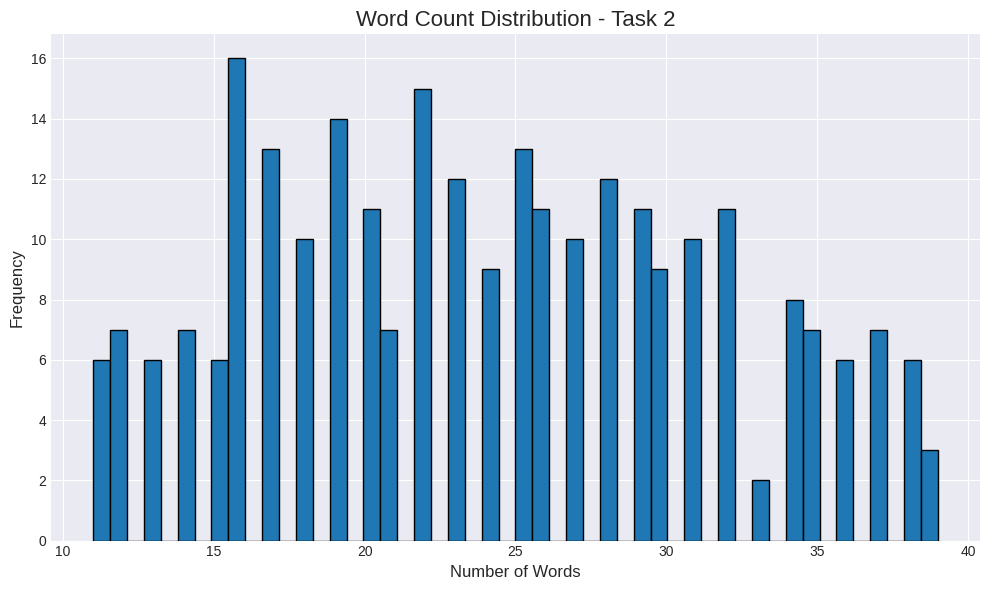

In [ ]:
plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(10, 6))
df_task2['word_count'].hist(bins=50, edgecolor='black')
plt.title("Word Count Distribution - Task 2", fontsize=16)
plt.xlabel("Number of Words", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

### Word Count Distribution for Task 3

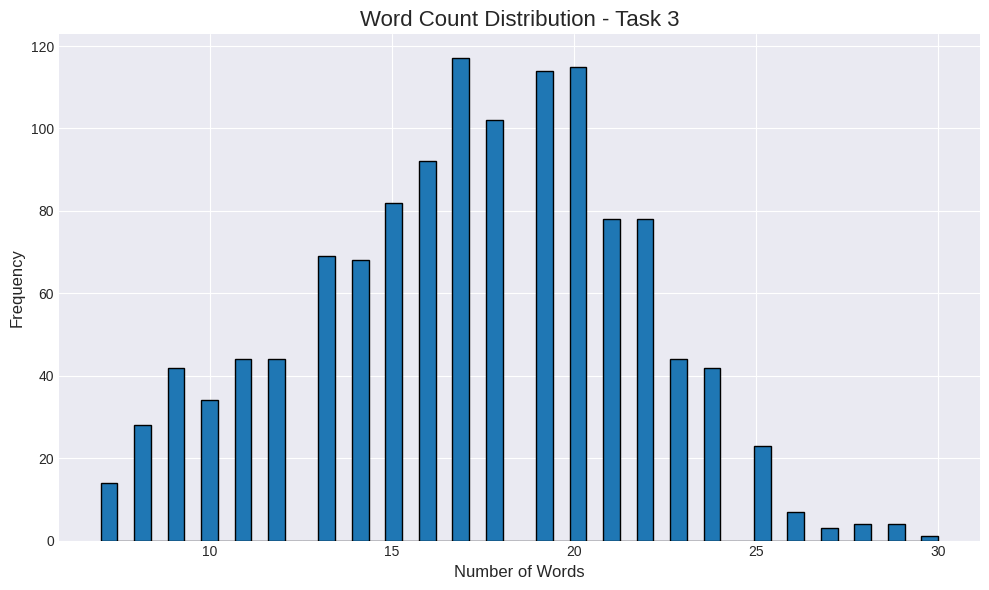

In [ ]:
plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(10, 6))
df_task3['word_count'] = df_task3['text'].apply(lambda x: len(x.split()))
df_task3['word_count'].hist(bins=50, edgecolor='black')
plt.title("Word Count Distribution - Task 3", fontsize=16)
plt.xlabel("Number of Words", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

### Word Count Distribution for Task 4

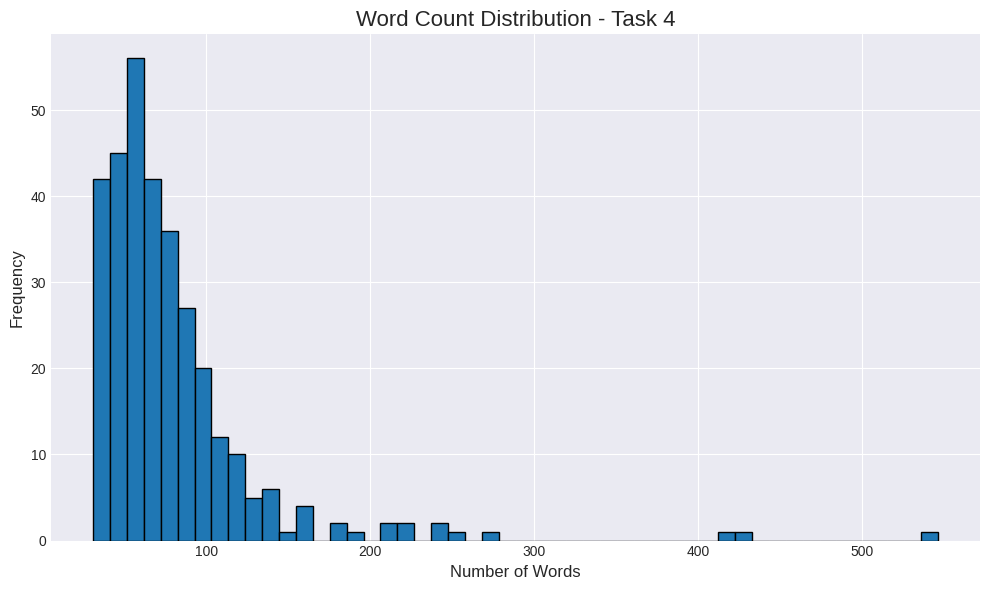

In [ ]:
plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(10, 6))
df_task4['word_count'] = df_task4['text'].apply(lambda x: len(x.split()))
df_task4['word_count'].hist(bins=50, edgecolor='black')
plt.title("Word Count Distribution - Task 4", fontsize=16)
plt.xlabel("Number of Words", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

### Statistical Summary of Word Counts

In [ ]:
print("Task 2 Word Count Summary:")
display(df_task2['word_count'].describe())

Task 2 Word Count Summary:


,word_count
count,265.000000
mean,24.147170
std,7.398111
min,11.000000
25%,18.000000
50%,24.000000
75%,30.000000
max,39.000000


In [ ]:
print("\nTask 3 Word Count Summary:")
display(df_task3['word_count'].describe())


Task 3 Word Count Summary:


,word_count
count,1249.000000
mean,17.104884
std,4.460408
min,7.000000
25%,14.000000
50%,17.000000
75%,20.000000
max,30.000000


In [ ]:
print("\nTask 4 Word Count Summary:")
display(df_task4['word_count'].describe())


Task 4 Word Count Summary:


,word_count
count,320.00000
mean,78.69375
std,54.29543
min,31.00000
25%,50.00000
50%,65.00000
75%,90.00000
max,546.00000


### Number of Labels After Preprocessing

In [ ]:
print("Task 2 Label Distribution after preprocessing:")
display(df_task2['label'].value_counts())

Task 2 Label Distribution after preprocessing:


,count
label,
0,198
1,67


In [ ]:
print("\nTask 3 Label Distribution after preprocessing:")
display(df_task3['label'].value_counts())


Task 3 Label Distribution after preprocessing:


,count
label,
0,715
1,304
2,230


In [ ]:
print("\nTask 4 Label Distribution after preprocessing:")
display(df_task4['label'].value_counts())


Task 4 Label Distribution after preprocessing:


,count
label,
1,163
0,106
2,51
